In [1]:
import sys
print(sys.executable)

/home/john-walkey/Data/Research/insula_dmn_project/env/bin/python


[fetch_atlas_schaefer_2018] Added README.md to /home/john-walkey/nilearn_data
[fetch_atlas_schaefer_2018] Dataset created in /home/john-walkey/nilearn_data/schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)



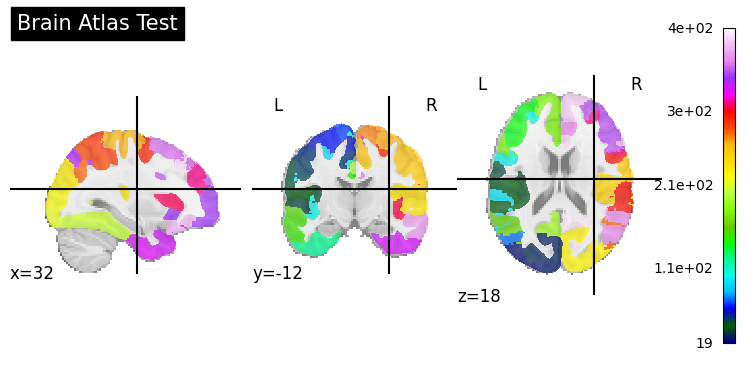

In [2]:
from nilearn import datasets
from nilearn import plotting

atlas = datasets.fetch_atlas_schaefer_2018()

plotting.plot_roi(atlas.maps, title="Brain Atlas Test")
plotting.show()

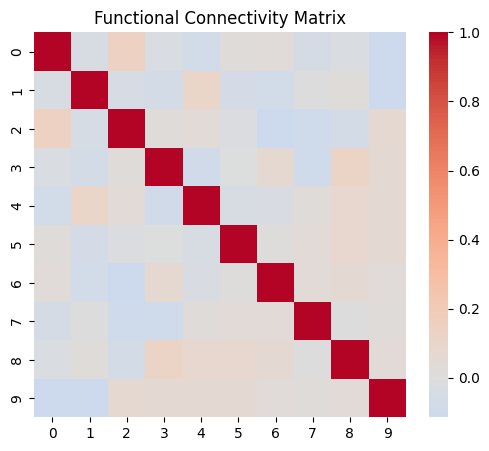

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# simulate time series for 10 brain regions
np.random.seed(42)
time_series = np.random.randn(200, 10)

# compute correlation matrix
connectivity = np.corrcoef(time_series.T)

# plot connectivity matrix
plt.figure(figsize=(6,5))
sns.heatmap(connectivity, cmap="coolwarm", center=0)
plt.title("Functional Connectivity Matrix")
plt.show()

Each column (above plot) represents a brain region.

Example:

Region 1 = Insula
Region 2 = mPFC
Region 3 = PCC
Region 4 = Angular gyrus
...

The heatmap shows how strongly the activity of each region correlates with every other region.

This is the core concept of functional connectivity.

In [4]:
insula_index = 0
dmn_indices = [1,2,3]

insula_dmn_connectivity = connectivity[insula_index, dmn_indices]

print("Insula–DMN connectivity values:")
print(insula_dmn_connectivity)

Insula–DMN connectivity values:
[-0.03789628  0.1467327  -0.02858543]


dentify Insula–DMN connections

Let’s simulate that region 0 is the insula and regions 1–3 are DMN.


This extracts the connections you care about.

In [5]:
mean_insula_dmn = np.mean(insula_dmn_connectivity)

print("Average insula–DMN connectivity:", mean_insula_dmn)

Average insula–DMN connectivity: 0.026750328997179596


Average DMN connectivity

- That value becomes your dependent variable.

Later you will test:

Trait anxiety → insula–DMN connectivity

What you just built

You now understand the basic pipeline:

fMRI time series
      ↓
correlation matrix
      ↓
extract network connections
      ↓
test hypothesis

That’s the same logic used in thousands of brain network papers.